In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [7]:
data = {
'Test_Coverage':[90,85,70,60,95,50,80,65],
'Open_Defects':[2,4,10,15,1,18,5,12],
'Automation':[80,75,60,50,90,40,70,55],
'Risk':[0,0,1,1,0,1,0,1]
}

df = pd.DataFrame(data)

X = df[['Test_Coverage','Open_Defects','Automation']]
y = df['Risk']
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.25,random_state=42
)

In [8]:
gini_model = DecisionTreeClassifier(criterion='gini')
gini_model.fit(X_train,y_train)
gini_pred = gini_model.predict(X_test)
print("Accuracy using Gini:",
      accuracy_score(y_test,gini_pred))

Accuracy using Gini: 1.0


In [9]:
entropy_model = DecisionTreeClassifier(criterion='entropy')
entropy_model.fit(X_train,y_train)
entropy_pred = entropy_model.predict(X_test)
print("Accuracy using Entropy:",
      accuracy_score(y_test,entropy_pred))

Accuracy using Entropy: 1.0


In [11]:
pruned_model = DecisionTreeClassifier(
criterion='gini',
max_depth=2
)
pruned_model.fit(X_train,y_train)
pruned_pred = pruned_model.predict(X_test)
print("Accuracy after Pruning:",    
accuracy_score(y_test,pruned_pred))

Accuracy after Pruning: 1.0


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
scatter = plt.scatter(df['Test_Coverage'], df['Open_Defects'], c=df['Risk'], cmap='coolwarm')
plt.xlabel('Test Coverage (%)')
plt.ylabel('Open Defects')
plt.title('Test Coverage vs Open Defects Colored by Risk')
plt.colorbar(scatter, label='Risk (0=Low, 1=High)')
plt.show()


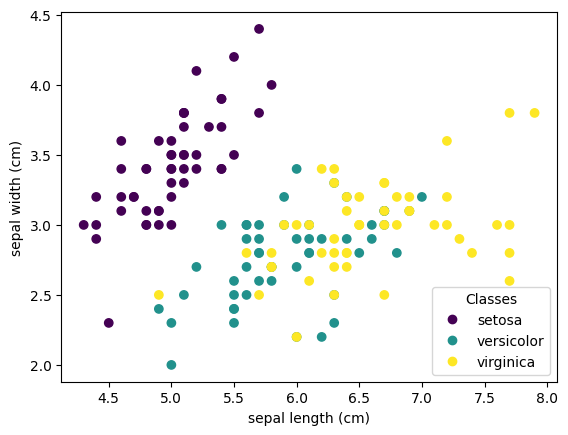

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
iris = datasets.load_iris()

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)
